# Causal Inference in Practice: Does PMO Escalation Support Actually Rescue At-Risk Projects?

**A hands-on project-management project built from Chapter 5 ("Propensity Score") of *Causal Inference in Python: Applying Causal Inference in the Tech Industry***

## The business problem

You work as a data scientist embedded in a company-wide **Project Management
Office (PMO)**. When a project starts showing early warning signs — schedule
slippage, scope creep, too many vendor dependencies — the PMO can step in with
**escalation support**: a senior PM is assigned to co-lead the project, weekly
steering-committee check-ins are added, and the team gets direct access to
executive sponsors to unblock decisions faster.

Leadership wants to know: **does PMO escalation support actually cause better final
project outcomes**, or is it simply being deployed on the projects that were always
going to struggle — making it *look* like the intervention doesn't help (or even
hurts), when it's really just correlated with already-troubled projects?

This is *structurally identical* to the "manager training" problem from Chapter 5:
a well-intentioned intervention that is **not randomly assigned**. The PMO
naturally prioritizes intervening on projects that look **at risk right now**
(behind schedule early, lots of scope changes, low baseline health score) — so a
naive before/after or treated-vs-control comparison will be badly biased, typically
making escalation support look useless or harmful, since the projects that receive
it were already trending toward a worse outcome.

## What you will practice in this notebook

Using the propensity-score toolkit from Chapter 5, applied end-to-end to a fresh,
realistic project-management dataset:

1. **Naive comparison** — see the bias for yourself
2. **Regression adjustment** — the Chapter 4 benchmark
3. **Propensity score estimation** — logistic regression modeling of the treatment
4. **Overlap / positivity diagnostics** — the check most people skip
5. **Propensity score matching** — nearest-neighbor matching on the propensity score
6. **Inverse Propensity Weighting (IPW)**, with **stabilized weights**
7. **Bootstrap confidence intervals** for IPW
8. **Doubly Robust (DR) estimation** — combining regression + IPW
9. A **bias–variance / positivity-violation demo** — why IPW can fail
10. A **bonus extension**: Generalized Propensity Score (GPS) for a **continuous
    treatment** — how much **extra contingency budget (%)** a project is allocated,
    and its causal effect on **schedule days saved** — this is a near-exact match
    to the bank interest-rate example in the book

Because the dataset is *simulated*, we know the **true causal effect** ahead of
time. That means at the end of the notebook you can literally check each
estimator's answer against the ground truth — the best way to build intuition for
when each method works and when it doesn't.

> **Note:** There's no bundled project-management dataset with the book, so this
> notebook generates a comparable, fully-documented synthetic dataset instead.
> Every simulation step is commented so you can see exactly how the confounding is
> built in — and you can swap in your own PPM tool's data later (Jira, Smartsheet,
> MS Project, Clarity PPM, etc.) by keeping the same treatment/outcome/confounder
> roles.


## 0. Setup

Same stack the book uses: `pandas`/`numpy` for data, `statsmodels` for OLS/logit
with nice formulas, `scikit-learn` for the ML-flavored propensity/outcome models,
`patsy` for building design matrices from formulas, and `joblib` for a parallel
bootstrap.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from patsy import dmatrix
from scipy.stats import norm
from joblib import Parallel, delayed
from functools import partial

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
np.random.seed(42)


## 1. Build the dataset

We simulate 8,000 projects closed out over the last few years. This is the only
part of the notebook where we "cheat" (we get to see the true causal effect) —
that's intentional, it's what lets us grade each estimator later.

**Confounders (X):**
- `team_size`: number of people staffed on the project
- `planned_duration_weeks`: how long the project was originally scoped to take
- `vendor_dependencies`: number of external vendors/teams the project depends on
- `requirements_changes`: number of major scope changes logged in the first
  quarter of the project
- `pre_intervention_health_score`: a baseline composite risk score (schedule
  variance + budget variance + stakeholder sentiment) measured at the point the
  PMO decides whether to escalate

**Treatment (T):** `pmo_escalation` — did the PMO assign escalation support
(senior PM + steering committee + exec sponsor access) to this project?

**Outcome (Y):** `final_health_score` — the project's final standardized health
score at close-out (combines on-time delivery, budget adherence, and stakeholder
satisfaction)

**The confounding we bake in:** the PMO is *more* likely to escalate projects that
look troubled early — i.e., projects with **more `requirements_changes`** and
**lower `pre_intervention_health_score`**. But those same projects also tend to end
up with **lower `final_health_score`** *regardless* of the escalation, simply
because they started off in worse shape. This is exactly the confounding pattern
from the book: the intervention is targeted at the projects that need it most,
which biases a naive comparison **downward**.


In [2]:
n = 8000

team_size = np.random.poisson(8, size=n) + 2
planned_duration_weeks = np.random.gamma(shape=3, scale=6, size=n).round(0) + 4
vendor_dependencies = np.random.poisson(1.2 + 0.03 * team_size, size=n)
requirements_changes = np.random.poisson(1.5 + 0.08 * vendor_dependencies, size=n)

pre_intervention_health_score = np.random.normal(
    0.55 - 0.22 * np.log1p(requirements_changes) - 0.01 * vendor_dependencies, 1.0
)

# --- treatment assignment mechanism (NOT random!) ---
# the PMO prioritizes escalation support for projects that already look at-risk
risk_score = (
    -1.05 * pre_intervention_health_score + 0.30 * requirements_changes + 0.05 * vendor_dependencies
)
true_propensity = 1 / (1 + np.exp(-(0.25 + 0.85 * risk_score)))
pmo_escalation = np.random.binomial(1, true_propensity)

# --- true causal effect of PMO escalation support on final project health ---
TRUE_ATE = 0.5
noise = np.random.normal(0, 0.6, n)
final_health_score = (
    pre_intervention_health_score
    + TRUE_ATE * pmo_escalation
    - 0.03 * vendor_dependencies
    - 0.02 * requirements_changes
    + noise
)

df = pd.DataFrame(
    dict(
        project_id=np.arange(n),
        team_size=team_size,
        planned_duration_weeks=planned_duration_weeks,
        vendor_dependencies=vendor_dependencies,
        requirements_changes=requirements_changes,
        pre_intervention_health_score=pre_intervention_health_score,
        pmo_escalation=pmo_escalation,
        final_health_score=final_health_score,
    )
)

print(f"True ATE (by construction): {TRUE_ATE}")
print(f"Share of projects that received PMO escalation support: {df['pmo_escalation'].mean():.1%}")
df.head()


True ATE (by construction): 0.5
Share of projects that received PMO escalation support: 57.6%


,project_id,team_size,planned_duration_weeks,vendor_dependencies,requirements_changes,pre_intervention_health_score,pmo_escalation,final_health_score
0,0,8,21.0,0,1,-0.168361,1,0.322554
1,1,9,26.0,1,2,1.147024,0,0.930721
2,2,8,30.0,2,1,0.507530,0,-0.854742
3,3,9,24.0,1,3,0.250026,0,-0.523745
4,4,9,16.0,1,1,0.558504,1,-0.527160


## 2. The naive comparison (and why it's wrong)

Just like the book's opening move in Chapter 5, let's first compute the simplest
possible estimate: the raw difference in mean `final_health_score` between
escalated and non-escalated projects.


In [3]:
naive_diff = (
    df.query("pmo_escalation == 1")["final_health_score"].mean()
    - df.query("pmo_escalation == 0")["final_health_score"].mean()
)
print(f"Naive difference in means: {naive_diff:.4f}")
print(f"True ATE:                 {TRUE_ATE:.4f}")


Naive difference in means: -0.2603
True ATE:                 0.5000


The naive estimate massively understates (or even flips the sign of) the true
benefit of PMO escalation support. This is exactly the trap the book warns about:
the "treatment" was aimed at projects that were already heading toward a worse
outcome, so comparing them directly to healthy projects makes escalation support
look useless or even harmful — when in fact it's helping.


## 3. Benchmark: regression adjustment

Before reaching for propensity scores, the book always sets a regression benchmark
first ("it's always a good idea to have some benchmark you trust to compare to").
We regress the outcome on treatment **and** all observed confounders.


In [4]:
reg_model = smf.ols(
    "final_health_score ~ pmo_escalation + pre_intervention_health_score "
    "+ requirements_changes + vendor_dependencies + team_size + planned_duration_weeks",
    data=df,
).fit()

reg_ate = reg_model.params["pmo_escalation"]
reg_ci = reg_model.conf_int().loc["pmo_escalation"].values

print(f"Regression-adjusted ATE: {reg_ate:.4f}")
print(f"95% CI:                  [{reg_ci[0]:.4f}, {reg_ci[1]:.4f}]")


Regression-adjusted ATE: 0.5118
95% CI:                  [0.4829, 0.5408]


Much closer to the truth. Regression removed most of the bias by explicitly
controlling for `pre_intervention_health_score`, `requirements_changes`,
`vendor_dependencies`, `team_size`, and `planned_duration_weeks`. Now let's get the
same kind of answer using the propensity-score machinery from the chapter — and see
that the two approaches agree.


## 4. The propensity score

The propensity score $e(x) = P(T=1 \mid X)$ is the probability that a project with
covariates $X$ receives PMO escalation support. The key theoretical result from the
chapter is that you don't need to condition on the (possibly high-dimensional) $X$
directly — conditioning on the **single number** $e(x)$ is enough to block the
backdoor path from $X$ into $T$:

$$(Y_1, Y_0) \perp T \mid X \quad \Longrightarrow \quad (Y_1, Y_0) \perp T \mid e(X)$$

Intuitively: two projects with the *same* probability of being escalated, one of
which got escalated and one which didn't, only differ by chance — so they're a
valid apples-to-apples comparison.

We estimate $\hat e(x)$ with a logistic regression, exactly as the book does.


In [5]:
ps_model = smf.logit(
    "pmo_escalation ~ pre_intervention_health_score + requirements_changes "
    "+ vendor_dependencies + team_size + planned_duration_weeks",
    data=df,
).fit(disp=0)

df["propensity_score"] = ps_model.predict(df)
df[["pmo_escalation", "final_health_score", "propensity_score"]].head()


,pmo_escalation,final_health_score,propensity_score
0,1,0.322554,0.655406
1,0,0.930721,0.441230
2,0,-0.854742,0.531553
3,0,-0.523745,0.688013
4,1,-0.527160,0.513928


## 5. Positivity / overlap diagnostic (don't skip this!)

The book stresses that IPW only works if there's **overlap**: for every region of
the covariate space, we need *both* escalated and non-escalated projects. If the
PMO escalates literally every project that shows early risk and literally no one
else, there's no data left to estimate what would have happened to an at-risk
project *without* escalation — a **positivity violation**.

Let's plot $\hat e(x)$ split by actual treatment status.


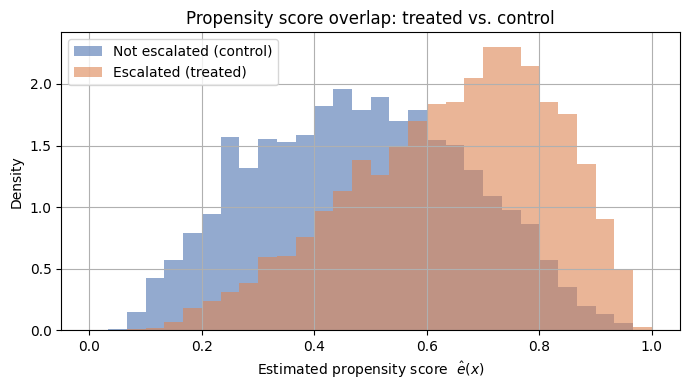

count    8000.000000
mean        0.576250
std         0.198521
min         0.041387
25%         0.430781
50%         0.591517
75%         0.735134
max         0.984490
Name: propensity_score, dtype: float64

Share of scores below 0.02 or above 0.98: 0.01%


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 31)
ax.hist(df.query("pmo_escalation == 0")["propensity_score"], bins=bins, alpha=0.6,
        label="Not escalated (control)", color="#4c72b0", density=True)
ax.hist(df.query("pmo_escalation == 1")["propensity_score"], bins=bins, alpha=0.6,
        label="Escalated (treated)", color="#dd8452", density=True)
ax.set_xlabel("Estimated propensity score  $\\hat e(x)$")
ax.set_ylabel("Density")
ax.set_title("Propensity score overlap: treated vs. control")
ax.legend()
plt.tight_layout()
plt.show()

print(df["propensity_score"].describe())
print("\nShare of scores below 0.02 or above 0.98:",
      f"{((df['propensity_score'] < 0.02) | (df['propensity_score'] > 0.98)).mean():.2%}")


Good news: the two distributions overlap substantially (escalated projects skew
higher, as expected, but there's no region owned exclusively by one group, and
almost no scores sit near the 0/1 extremes). This tells us IPW should behave well
here — a very different story from the positivity-violation example we'll build in
Section 9.


## 6. Propensity score matching

As a first way to *use* the propensity score, we match each escalated project to
its nearest-neighbor (by $\hat e(x)$) among non-escalated projects, and vice versa,
then average the outcome differences within matched pairs. This is the $K=1$ KNN
approach the book walks through.

> The book itself is lukewarm on this estimator (biased, hard to get standard
> errors for, and inefficient in high dimensions) — we include it here mainly so
> you can see *why* IPW tends to be preferred in practice.


In [7]:
T, X_ps, Y = "pmo_escalation", "propensity_score", "final_health_score"

treated = df.query(f"{T} == 1")
control = df.query(f"{T} == 0")

# match every control unit to its nearest treated unit (to impute Y1 for controls)
knn_treated = KNeighborsRegressor(n_neighbors=1).fit(treated[[X_ps]], treated[Y])
# match every treated unit to its nearest control unit (to impute Y0 for treated)
knn_control = KNeighborsRegressor(n_neighbors=1).fit(control[[X_ps]], control[Y])

matched = pd.concat([
    treated.assign(match=knn_control.predict(treated[[X_ps]])),
    control.assign(match=knn_treated.predict(control[[X_ps]])),
])

matching_ate = np.mean(
    (matched[Y] - matched["match"]) * matched[T]
    + (matched["match"] - matched[Y]) * (1 - matched[T])
)
print(f"Propensity score matching ATE: {matching_ate:.4f}")


Propensity score matching ATE: 0.4838


## 7. Inverse Propensity Weighting (IPW)

IPW reweights each project by the inverse probability of the treatment it actually
received, creating a *pseudo-population* in which treatment looks as good as
randomly assigned:

$$ATE = E\!\left[\frac{\mathbb{1}(T=1)\,Y}{\hat e(X)}\right] - E\!\left[\frac{\mathbb{1}(T=0)\,Y}{1-\hat e(X)}\right]$$

which simplifies (as in the book) to the single-expression form:

$$ATE = E\!\left[Y \cdot \frac{T - \hat e(X)}{\hat e(X)(1-\hat e(X))}\right]$$


In [8]:
weight_treated = 1 / df.query(f"{T} == 1")[X_ps]
weight_control = 1 / (1 - df.query(f"{T} == 0")[X_ps])

y1_hat = (df.query(f"{T} == 1")[Y] * weight_treated).sum() / len(df)
y0_hat = (df.query(f"{T} == 0")[Y] * weight_control).sum() / len(df)

ipw_ate = y1_hat - y0_hat
print(f"E[Y1] = {y1_hat:.4f}")
print(f"E[Y0] = {y0_hat:.4f}")
print(f"IPW ATE = {ipw_ate:.4f}")

# sanity check: the single-expression formula should give the exact same number
ipw_ate_check = np.mean(
    df[Y] * (df[T] - df[X_ps]) / (df[X_ps] * (1 - df[X_ps]))
)
print(f"IPW ATE (single-formula check) = {ipw_ate_check:.4f}")


E[Y1] = 0.7977
E[Y0] = 0.2814
IPW ATE = 0.5162
IPW ATE (single-formula check) = 0.5162


### Stabilized weights

Raw IPW weights can blow up when $\hat e(x)$ is close to 0 or 1. **Stabilizing** the
weights by the marginal probability of treatment, $P(T=t)$, keeps the *effective*
sample size close to the original sample size while giving the exact same point
estimate.


In [9]:
p_of_t = df[T].mean()
t1, t0 = df.query(f"{T} == 1"), df.query(f"{T} == 0")

w_t_stable = p_of_t / t1[X_ps]
w_nt_stable = (1 - p_of_t) / (1 - t0[X_ps])

print("Original sample size:              ", len(df))
print("Escalated pseudo-population size:  ", round(w_t_stable.sum(), 1), " (actual escalated n =", len(t1), ")")
print("Non-escalated pseudo-population:   ", round(w_nt_stable.sum(), 1), " (actual non-escalated n =", len(t0), ")")

ipw_ate_stable = (
    (t1[Y] * w_t_stable).sum() / len(t1) - (t0[Y] * w_nt_stable).sum() / len(t0)
)
print(f"\nStabilized IPW ATE: {ipw_ate_stable:.4f}  (matches the unstabilized estimate, as expected)")


Original sample size:               8000
Escalated pseudo-population size:   4615.5  (actual escalated n = 4610 )
Non-escalated pseudo-population:    3391.0  (actual non-escalated n = 3390 )

Stabilized IPW ATE: 0.5162  (matches the unstabilized estimate, as expected)


## 8. Bootstrap confidence interval for IPW

Unlike OLS, IPW doesn't have a clean closed-form standard error, so — following the
book — we wrap the whole estimation procedure (propensity model + weighting) into a
single function and bootstrap it.


In [10]:
def est_ate_with_ps(data, ps_formula, T, Y):
    # Fit a propensity model with sklearn's LogisticRegression and return the IPW ATE.
    Xmat = dmatrix(ps_formula, data)
    ps_model = LogisticRegression(max_iter=1000, C=1e6).fit(Xmat, data[T])
    ps = ps_model.predict_proba(Xmat)[:, 1]
    return np.mean(data[Y] * (data[T] - ps) / (ps * (1 - ps)))


def bootstrap(data, est_fn, rounds=300, seed=0, pcts=(2.5, 97.5), n_jobs=4):
    np.random.seed(seed)
    stats = Parallel(n_jobs=n_jobs)(
        delayed(est_fn)(data.sample(frac=1, replace=True)) for _ in range(rounds)
    )
    point = est_fn(data)
    return point, np.percentile(stats, pcts)


ps_formula = ("pre_intervention_health_score + requirements_changes + vendor_dependencies "
              "+ team_size + planned_duration_weeks")
ipw_fn = partial(est_ate_with_ps, ps_formula=ps_formula, T=T, Y=Y)

ipw_point, ipw_ci = bootstrap(df, ipw_fn, rounds=300)
print(f"IPW ATE: {ipw_point:.4f}")
print(f"95% CI:  [{ipw_ci[0]:.4f}, {ipw_ci[1]:.4f}]")


IPW ATE: 0.5162
95% CI:  [0.4785, 0.5595]


## 9. Doubly Robust (DR) estimation

DR combines an **outcome model** $\hat m(X)$ (like regression) with a **propensity
model** $\hat e(X)$ (like logistic regression) so that the estimate is consistent if
*either one* of the two models is correctly specified — you get two chances to be
right instead of one:

$$\hat\mu^{DR}_t(\hat m, \hat e) = \frac{1}{N}\sum \hat m(X) + \frac{1}{N}\sum\left[\frac{T}{\hat e(x)}\big(Y - \hat m(X)\big)\right]$$

$$ATE = \hat\mu^{DR}_1(\hat m, \hat e) - \hat\mu^{DR}_0(\hat m, \hat e)$$


In [11]:
def doubly_robust(data, formula, T, Y):
    Xmat = dmatrix(formula, data)

    ps_model = LogisticRegression(max_iter=1000, C=1e6).fit(Xmat, data[T])
    ps = ps_model.predict_proba(Xmat)[:, 1]

    m0 = LinearRegression().fit(Xmat[data[T] == 0], data[Y][data[T] == 0])
    m1 = LinearRegression().fit(Xmat[data[T] == 1], data[Y][data[T] == 1])
    m0_hat, m1_hat = m0.predict(Xmat), m1.predict(Xmat)

    mu1 = np.mean(data[T] * (data[Y] - m1_hat) / ps + m1_hat)
    mu0 = np.mean((1 - data[T]) * (data[Y] - m0_hat) / (1 - ps) + m0_hat)
    return mu1 - mu0


dr_fn = partial(doubly_robust, formula=ps_formula, T=T, Y=Y)
dr_point, dr_ci = bootstrap(df, dr_fn, rounds=300)

print(f"Doubly robust ATE: {dr_point:.4f}")
print(f"95% CI:            [{dr_ci[0]:.4f}, {dr_ci[1]:.4f}]")


Doubly robust ATE: 0.5092
95% CI:            [0.4775, 0.5428]


## 10. Scoreboard: comparing every estimator against the truth

Since this is simulated data, we get to check our homework.


In [12]:
results = pd.DataFrame(
    [
        ("Naive difference in means", naive_diff, np.nan, np.nan),
        ("Regression adjustment", reg_ate, reg_ci[0], reg_ci[1]),
        ("Propensity score matching (K=1)", matching_ate, np.nan, np.nan),
        ("IPW (bootstrap CI)", ipw_point, ipw_ci[0], ipw_ci[1]),
        ("Doubly robust (bootstrap CI)", dr_point, dr_ci[0], dr_ci[1]),
    ],
    columns=["Method", "ATE estimate", "CI low", "CI high"],
)
results["Error vs. true ATE"] = results["ATE estimate"] - TRUE_ATE
results = results.round(4)
results


,Method,ATE estimate,CI low,CI high,Error vs. true ATE
0,Naive difference in means,-0.2603,NaN,NaN,-0.7603
1,Regression adjustment,0.5118,0.4829,0.5408,0.0118
2,Propensity score matching (K=1),0.4838,NaN,NaN,-0.0162
3,IPW (bootstrap CI),0.5162,0.4785,0.5595,0.0162
4,Doubly robust (bootstrap CI),0.5092,0.4775,0.5428,0.0092


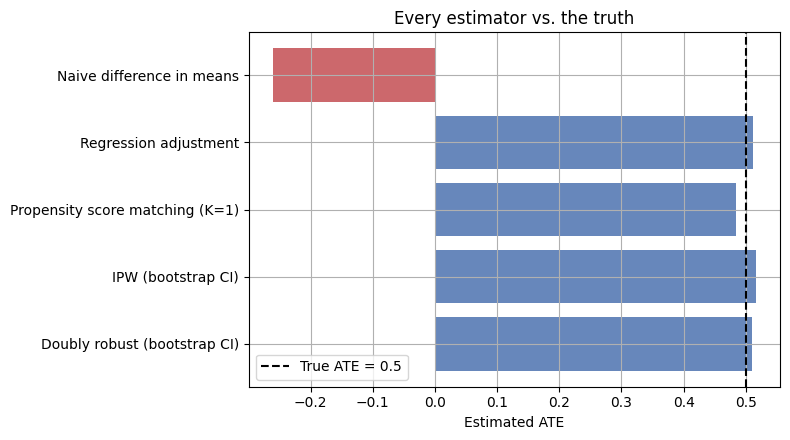

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(results))
colors = ["#c44e52" if m == "Naive difference in means" else "#4c72b0" for m in results["Method"]]
ax.barh(y_pos, results["ATE estimate"], color=colors, alpha=0.85)
ax.axvline(TRUE_ATE, color="black", linestyle="--", linewidth=1.5, label=f"True ATE = {TRUE_ATE}")
ax.set_yticks(y_pos)
ax.set_yticklabels(results["Method"])
ax.set_xlabel("Estimated ATE")
ax.set_title("Every estimator vs. the truth")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Every bias-adjusted method lands close to the true effect of `0.5`; only the
naive comparison is way off. This is the core lesson of the chapter: **regression,
matching, IPW, and DR are all different ways of doing the same underlying job** —
making escalated and non-escalated projects comparable by adjusting for the
treatment assignment mechanism.


## 11. When IPW breaks: a positivity-violation stress test

The book is careful to point out that IPW is *not* magic — if the propensity model
is "too good" (i.e., it near-perfectly separates escalated from non-escalated
projects), the weights explode and the estimator becomes unusable, even though
regression, which *extrapolates*, might still get close to the right answer.

Let's build a small toy dataset with almost no overlap — imagine `x` is an
**early risk score** that almost deterministically decides whether the PMO
escalates the project — exactly like the book's Section on "Positivity", and watch
IPW struggle while regression (helped by a smooth, correctly-specified functional
form) survives.


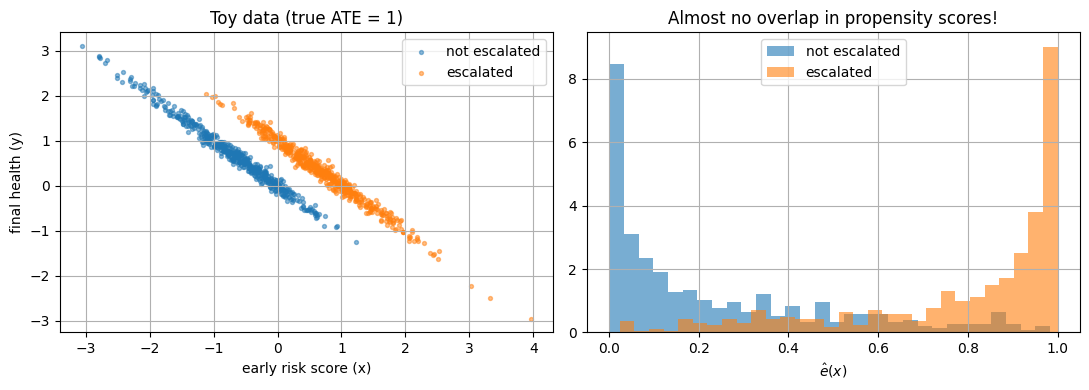

In [14]:
np.random.seed(1)
n_toy = 1000
risk = np.random.normal(0, 1, n_toy)               # early project risk score
escalated = (np.random.normal(risk, 0.5, n_toy) > 0).astype(int)  # escalation strongly tied to risk

# without escalation, health gets worse the riskier the project started
health0_toy = -risk
health1_toy = health0_toy + 1  # true ATE = 1 (escalation always helps by +1)
health_toy = np.random.normal((1 - escalated) * health0_toy + escalated * health1_toy, 0.1)

df_toy = pd.DataFrame(dict(x=risk, t=escalated, y=health_toy))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df_toy.query("t==0")["x"], df_toy.query("t==0")["y"], s=8, label="not escalated", alpha=0.5)
axes[0].scatter(df_toy.query("t==1")["x"], df_toy.query("t==1")["y"], s=8, label="escalated", alpha=0.5)
axes[0].set_title("Toy data (true ATE = 1)")
axes[0].set_xlabel("early risk score (x)"); axes[0].set_ylabel("final health (y)"); axes[0].legend()

ps_toy = smf.logit("t ~ x", data=df_toy).fit(disp=0).predict(df_toy)
axes[1].hist(ps_toy[df_toy.t == 0], bins=30, alpha=0.6, label="not escalated", density=True)
axes[1].hist(ps_toy[df_toy.t == 1], bins=30, alpha=0.6, label="escalated", density=True)
axes[1].set_title("Almost no overlap in propensity scores!")
axes[1].set_xlabel("$\\hat e(x)$"); axes[1].legend()
plt.tight_layout()
plt.show()


In [15]:
# IPW on the near-violation data
ipw_toy_point, ipw_toy_ci = bootstrap(df_toy, partial(est_ate_with_ps, ps_formula="x", T="t", Y="y"), rounds=200)
print(f"IPW ATE on toy data:        {ipw_toy_point:.4f}   95% CI [{ipw_toy_ci[0]:.4f}, {ipw_toy_ci[1]:.4f}]  (true ATE = 1)")

# Regression on the same data
reg_toy = smf.ols("y ~ x + t", data=df_toy).fit()
print(f"Regression ATE on toy data: {reg_toy.params['t']:.4f}")


IPW ATE on toy data:        0.6527   95% CI [0.4692, 0.8361]  (true ATE = 1)
Regression ATE on toy data: 1.0083


IPW's confidence interval is wide **and often doesn't even contain the true value
of 1** — it's not just imprecise, it's biased, because there simply isn't enough
data in some regions to reconstruct the missing counterfactual (almost no high-risk
projects go without escalation, and almost no low-risk projects get escalated).
Regression, by contrast, smoothly extrapolates across `x` and recovers the true
effect almost exactly. This is the practical version of the book's "Design- vs.
Model-Based Identification" discussion: IPW makes no assumption on the shape of
$E[Y \mid X]$, so when the design (positivity) fails, it has nothing to fall back
on. This is also *why* doubly robust estimation is so attractive — it gives you a
second chance if positivity is shaky but your outcome model is reasonable.


## 12. Bonus: continuous treatment with the Generalized Propensity Score

So far, `pmo_escalation` has been binary. But PMOs also run **continuous**
interventions — the clearest example is **contingency budget allocation**: a
resource-planning algorithm grants each project an extra **contingency budget %**
on top of its baseline, based on the project's risk profile, and you want to know
its causal effect on **schedule days saved** versus the original plan. This mirrors
the book's bank interest-rate example almost exactly (interest rate → loan duration
becomes contingency budget % → schedule days saved).

The problem: $P(T=t \mid X) = 0$ for any continuous $t$, so we can't use a plain
propensity score. Instead we model the **conditional density** $f(T \mid X)$,
assuming (as the book does) that $T \mid X \sim \mathcal N(\mu(X), \sigma^2)$, and
reweight by the inverse of that density (stabilized by the marginal density
$f(T)$) — the **Generalized Propensity Score (GPS)**.


In [16]:
np.random.seed(7)  # local seed so this section is reproducible on its own

n_c = 10000
complexity_risk_score = np.random.normal(0, 1, n_c)  # e.g., a project-complexity risk model
vendor_risk_score = np.random.normal(0, 1, n_c)       # e.g., a vendor-dependency risk model

# contingency budget % assigned based on the two risk scores + noise -> continuous, confounded treatment
# (we deliberately do NOT clip the treatment: clipping truncates the tails and breaks
#  the Normal conditional-density assumption the GPS below relies on)
contingency_pct = 10 + 1.0 * complexity_risk_score - 0.6 * vendor_risk_score + np.random.normal(0, 3.0, n_c)

TRUE_SLOPE = 0.5  # true causal effect: +1pt contingency budget -> +0.5 schedule days saved
schedule_days_saved = (
    TRUE_SLOPE * contingency_pct + 1.8 * complexity_risk_score - 1.3 * vendor_risk_score
    + np.random.normal(0, 2, n_c)
)

df_cont = pd.DataFrame(dict(
    complexity_risk_score=complexity_risk_score,
    vendor_risk_score=vendor_risk_score,
    contingency_pct=contingency_pct,
    schedule_days_saved=schedule_days_saved,
))

naive_cont = smf.ols("schedule_days_saved ~ contingency_pct", data=df_cont).fit()
print("Naive (unadjusted) slope:", round(naive_cont.params["contingency_pct"], 4))
print("True slope:              ", TRUE_SLOPE)


Naive (unadjusted) slope: 0.7444
True slope:               0.5


In [17]:
# Step 1: model the conditional mean of the treatment given confounders
treatment_model = smf.ols("contingency_pct ~ complexity_risk_score + vendor_risk_score", data=df_cont).fit()
mu_i = treatment_model.fittedvalues
sigma = np.std(treatment_model.resid)

# Step 2: evaluate the conditional density f(T=t | X) at the observed treatment (the GPS)
gps = norm(loc=mu_i, scale=sigma).pdf(df_cont["contingency_pct"])

# Step 3: stabilize with the marginal density f(T=t)
marginal_density = norm(
    loc=df_cont["contingency_pct"].mean(), scale=np.std(df_cont["contingency_pct"])
).pdf(df_cont["contingency_pct"])

gps_weight_stable = marginal_density / gps

print("Original sample size:                  ", len(df_cont))
print("Effective sample size (stabilized GPS): ", round(gps_weight_stable.sum(), 1))

# Step 4: weighted regression to recover the causal slope
gps_model = smf.wls("schedule_days_saved ~ contingency_pct", data=df_cont, weights=gps_weight_stable).fit()
print("\nGPS-weighted slope:", round(gps_model.params["contingency_pct"], 4))
print("True slope:        ", TRUE_SLOPE)


Original sample size:                   10000
Effective sample size (stabilized GPS):  10001.7

GPS-weighted slope: 0.5043
True slope:         0.5


The GPS-weighted regression lands much closer to the true causal slope than the
naive (unadjusted) regression, which stays badly biased by the confounding
relationship between `complexity_risk_score`, `vendor_risk_score`,
`contingency_pct`, and `schedule_days_saved`. Exactly as the book emphasizes,
weight **stabilization is not optional** here — try removing the
`marginal_density` numerator above and re-running; the raw weights get far larger
and the estimate becomes much noisier.

Also notice, as the book warns, that GPS is touchier than the discrete-treatment
IPW case: it leans on a **parametric assumption** (`contingency_pct | X` is Normal
with constant variance) that has to hold reasonably well, and a handful of projects
with unlikely contingency allocations given their risk scores can end up with
outsized weights. This is exactly why the book's author personally prefers plain
regression adjustment once the treatment is continuous, reaching for GPS mainly as
a way to build intuition about *why* IPW works the way it does.


## 13. Key takeaways

| Method | What it assumes | When to reach for it |
|---|---|---|
| **Regression adjustment** | Correct functional form for $E[Y\mid T,X]$ | Good default; handles extrapolation; great for continuous treatments |
| **Propensity score matching** | Correct $e(X)$; enough neighbors nearby | Rarely the first choice — biased and hard to get SEs for |
| **IPW** | Correct $e(X)$; **positivity** (overlap) | Discrete treatment, and you trust your model of *how* treatment was assigned |
| **Doubly robust (DR)** | Correct $e(X)$ **or** correct $E[Y\mid T,X]$ | Discrete treatment; the safest default — "two shots at being right" |
| **Generalized Propensity Score (GPS)** | Correct conditional density of $T\mid X$ (e.g. Normal) | Continuous treatment when you specifically want a design-based approach; otherwise the book recommends leaning on regression |

**The single biggest idea in this notebook:** an intervention that gets targeted at
the projects that need it most (or least) will *always* look biased in a naive
comparison. The fix is never "just compare the two groups" — it's to explicitly
model either the **outcome** (regression), the **treatment assignment** (propensity
methods), or both (doubly robust).

## Other project-management questions this exact toolkit can answer

- Does **assigning a dedicated QA engineer** to a project reduce post-launch defect
  counts? (QA staffing is rarely random — it's usually concentrated on projects
  that already look higher-risk)
- Does adopting **agile/scrum** on a project (vs. waterfall) change delivery
  predictability? (team leads often self-select agile for projects they already
  expect to be more dynamic — a classic confounded "treatment")
- Does **more frequent stakeholder demos** (a near-continuous treatment: demos per
  month) improve final stakeholder satisfaction? (a natural second GPS use case)
- Does an **external audit/review** midway through a program reduce final cost
  overrun? (audits are usually triggered by early warning signs, exactly the
  "manager training" confounding pattern)

## Ideas to extend this project

- Swap in a **machine learning model** (e.g., gradient boosting) for $\hat e(x)$
  instead of logistic regression — remember to use `predict_proba`, calibrate it,
  and get out-of-fold predictions with `cross_val_predict` to avoid overfitting
  bias, as the book's sidebar recommends.
- Add a **"noise-inducing" covariate** — one that predicts escalation perfectly but
  has no effect on final health — and watch the IPW variance explode even though
  bias doesn't improve. This is the book's Chapter 4 lesson resurfacing in the
  propensity-score context.
- Try **weight trimming/clipping** (e.g., clip $\hat e(x)$ to $[0.01, 0.99]$) on the
  Section 11 toy data and see how the bias–variance trade-off shifts.
- Replace the simulated dataset with **real PPM tool data** from your own
  organization (Jira, MS Project, Smartsheet, Clarity), keeping the same
  treatment/outcome/confounder roles — most PPM systems already log baseline
  schedule variance, scope-change counts, and closeout health scores in a form
  very close to this schema.
